# 6.3 Neural Network with Julia Continued

In [44]:
using Zygote
using Lux
using Random
using Distributions
using CairoMakie
using Optimisers
using Optimization
using OptimizationOptimisers
using ComponentArrays

So far, we have built relatively simple Neural Network with Julia.  We can use the `Lux()` package in Julia to build very complex Neural Networks in Julia.  I will give some examples here. To construct the Neural Network below, 

![Alt text for screen readers](../figures/03p03Fig03.svg)

you can use the following Julia code

In [45]:
model = Chain(Dense(1 => 2,tanh),
            Dense(2=>1))


Chain(
    layer_1 = Dense(1 => 2, tanh),                # 4 parameters
    layer_2 = Dense(2 => 1),                      # 3 parameters
)         # Total: 7 parameters,
          #        plus 0 states.

This Neural Network has 1 hidden layer with 2 nodes, 1 input and 1 output.  

The next Neural Network below also has 1 input and 1 output and has 2 hidden layers with 4 and 6 nodes respectively.  

![Alt text for screen readers](../figures/03p03Fig07.svg)

The code to construct this Neural Network using Lux in Julia is

In [46]:
model = Chain(Dense(1 => 4,tanh),
            Dense(4=>6,tanh),
Dense(6=>1))


Chain(
    layer_1 = Dense(1 => 4, tanh),                # 8 parameters
    layer_2 = Dense(4 => 6, tanh),                # 30 parameters
    layer_3 = Dense(6 => 1),                      # 7 parameters
)         # Total: 45 parameters,
          #        plus 0 states.

---

So far, we have trained and conducted our predictions using all our data.  This is a bit pointless because if we already have our data, then why do we need a model to do our predictions.  The main reason for having a model is that you want to predict where you do not have data!  Let's randomly pick 50% of our data set and then try to train our model to predict the other 50%.  The data that we use to train our model is called the training dataset and the other data that we use to test our model is usually called the validation dataset. 


Generate data using the function

$h(x)=2\cos(\pi x)\exp(-x^2/5)$

for $x\in [0,5]$.  We also add a bit of random noise to our data. 

In [47]:
N_SAMPLES=100
xdata=5*rand(N_SAMPLES)
h(x)=2.0cos(pi *x )*exp(-x^2/5)
ydata=h.(xdata).+0.05*randn(N_SAMPLES)

100-element Vector{Float64}:
 -0.17619228051694247
 -1.7274756929111315
 -0.7978215087224122
 -0.19509082769413835
 -1.7603478855316192
  0.8662223312958148
  0.5976289516342747
 -0.8136904227827861
  0.04407056574901293
  0.36848817771805303
  ⋮
  0.3303569054410371
  0.9286929364896507
  0.05983233749487957
 -0.25858989263775706
  0.8821441593661695
  0.763685119665301
  1.7352061081875674
  0.047096806322561045
 -0.7892209947566635

Let's see how our data looks like

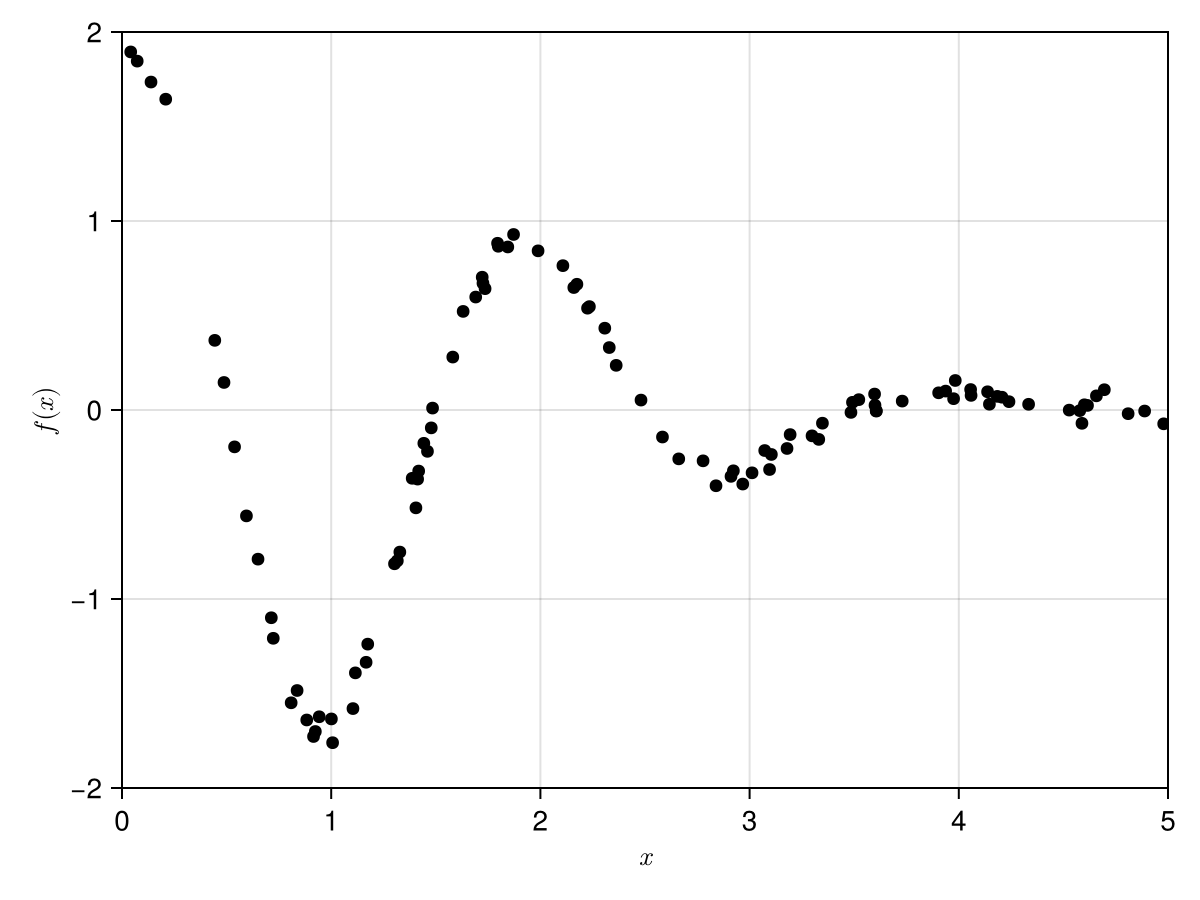

In [48]:
fig = Figure(backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor = :transparent,limits = (0,5, -2, 2))
scatter!(ax,xdata,ydata;color=:black,label="data")
#save("../figures/06p03NeuralNetworkWithJuliaPart2.png",fig)
fig


Let's select our training data randomly from our whoe dataset .  We will pick 50%.

In [49]:
#training_indices=rand(eachindex(xdata),round(Int,0.5*N_SAMPLES))
training_indices=shuffle(eachindex(xdata))[1:round(Int,0.5*N_SAMPLES)]
xtraining=xdata[training_indices]
ytraining=ydata[training_indices]

50-element Vector{Float64}:
  1.8944663310765575
 -0.06977014543375529
  0.0101077746154251
 -0.7892209947566635
 -0.3613950081322883
  0.04407056574901293
 -0.7517086975032635
 -0.005763541687452252
 -0.09458407956554007
  0.08435989368157731
  ⋮
 -1.7274756929111315
  0.04058696766057787
 -0.0005708323373534076
 -0.019534510618887793
  0.9286929364896507
 -0.25858989263775706
  1.7352061081875674
 -1.7603478855316192
  0.05983233749487957

Plotting our training data with the original dataset

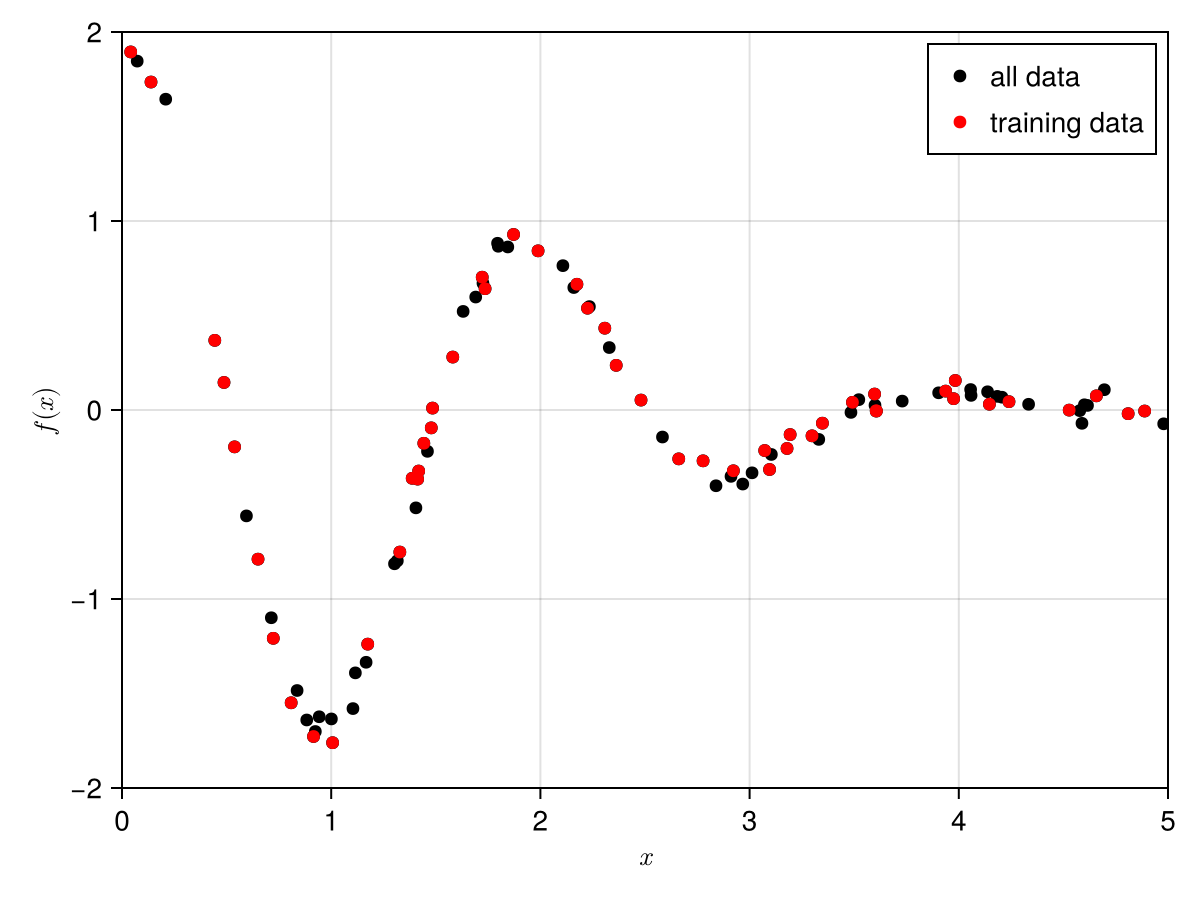

In [50]:
fig = Figure(backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor = :transparent,limits = (0,5, -2, 2))
scatter!(ax,xdata,ydata;color=:black,label="all data")
scatter!(ax,xtraining,ytraining;color=:red,label="training data")
axislegend(ax,location=:rt)
save("../figures/06p03NeuralNetworkWithJuliaPart204.png",fig)
fig

Choosing a model 

In [51]:
model_training = Chain(Dense(1 => 5,tanh),
Dense(5 => 5,tanh),
Dense(5=>1))

# Initialize the model weights and state
rng = Random.default_rng()
ps, ls = Lux.setup(rng, model_training)

((layer_1 = (weight = Float32[2.8126822; 0.43456358; … ; -2.8000252; 0.013202454;;], bias = Float32[-0.15028763, 0.7801498, 0.74896264, 0.18760526, -0.06775844]), layer_2 = (weight = Float32[-0.83308905 0.96173835 … -0.4421943 0.09656086; 1.0911583 -0.016539475 … -0.048167467 1.20371; … ; -0.9608359 -0.8736775 … 0.011510532 -1.0125556; -1.2570175 0.5195003 … -1.0770085 -1.0715384], bias = Float32[0.3824637, -0.33159572, -0.4125466, -0.28877118, 0.37937763]), layer_3 = (weight = Float32[0.0795809 0.2588633 … -0.13799204 -0.3825596], bias = Float32[0.36268836])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Training the model

In [52]:
# The forward function
function loss_training(ps, ytraining)
    ypred,_=model_training(xtraining', ps, ls)
    loss = 0.5 * mean((ypred.-ytraining').^2)
    return loss
end

callback = function (p, l)
    if length(loss_history) % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction(loss_training, adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(ps),ytraining)

# Initialize a vector to store loss values
loss_history = Float64[]
neural_network = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.01); callback, maxiters = 10000)

ps=neural_network.u

Iteration: 1, Loss: 0.254238502440033
Iteration: 101, Loss: 0.07229499495070398
Iteration: 201, Loss: 0.03990792317391949
Iteration: 301, Loss: 0.010942156530960933
Iteration: 401, Loss: 0.006577881702759839
Iteration: 501, Loss: 0.005331070456983286
Iteration: 601, Loss: 0.0048544594725865664
Iteration: 701, Loss: 0.004045458991332544
Iteration: 801, Loss: 0.001665626523497666
Iteration: 901, Loss: 0.0015013561457149415
Iteration: 1001, Loss: 0.0014659504005923151
Iteration: 1101, Loss: 0.0014352300758489894
Iteration: 1201, Loss: 0.0014097859072605065
Iteration: 1301, Loss: 0.0013800216195493532
Iteration: 1401, Loss: 0.0014331328102896485
Iteration: 1501, Loss: 0.001334330560734152
Iteration: 1601, Loss: 0.0013342386397238331
Iteration: 1701, Loss: 0.0012965366734857535
Iteration: 1801, Loss: 0.001280829715053274
Iteration: 1901, Loss: 0.0012653165847344937
Iteration: 2001, Loss: 0.0012527994110926378
Iteration: 2101, Loss: 0.0012395955789379878
Iteration: 2201, Loss: 0.001228955046

ComponentVector{Float32}(layer_1 = (weight = Float32[0.9475966; 0.36262026; … ; -2.8164363; 1.345231;;], bias = Float32[-3.2317116, 0.7757226, 2.049569, 1.275323, -1.0862648]), layer_2 = (weight = Float32[-4.070168 -0.28890327 … 1.5390081 -0.122155175; 1.7381042 0.10027236 … 0.016227687 2.8701613; … ; -1.5142974 -0.81499857 … -0.8636703 -4.3408318; -1.5063072 -0.47521445 … -2.0323236 -2.5473473], bias = Float32[-1.0695869, -0.36234817, 0.48897162, -0.2130592, -0.6517164]), layer_3 = (weight = Float32[3.3093107 1.791892 … -0.4240285 -1.6611755], bias = Float32[0.43222436]))

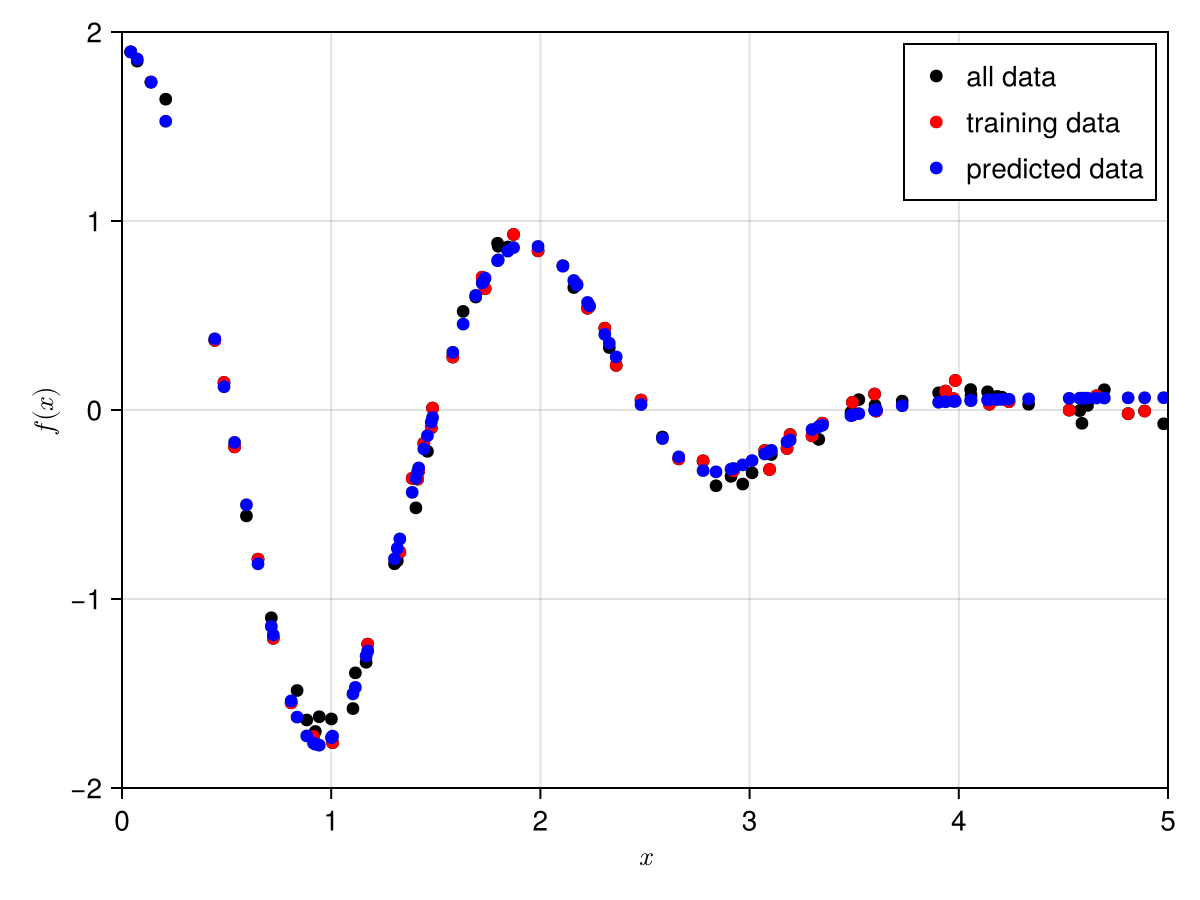

In [53]:
fig = Figure(backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor = :transparent,limits = (0,5, -2, 2))
scatter!(ax,xdata,ydata;color=:black,label="all data")
scatter!(ax,xtraining,ytraining;color=:red,label="training data")
scatter!(ax,xdata,model_training(xdata',ps,ls)[1][:];color=:blue,label="predicted data")
axislegend(ax,location=:rt)
save("../figures/06p03NeuralNetworkWithJuliaPart205.png",fig)
fig

As expected, if you randomly pick your training data for $0<x<5$ and you train your model in this region, then your prediction in this region is going to be good.

You can find the mean of the square of the error between the model and the validation dataset by using the code below

In [54]:
validation_indices=setdiff(1:N_SAMPLES,training_indices)
ypred,_=model_training(xdata[validation_indices]', ps, ls)
mean((ypred.-ydata[validation_indices]').^2)

0.004846285932211208

---


What we have done so far is to train the model with data in the region $x\in [0,5]$ and then predict the data $x\in [0,5]$. This is a bit pointless because if we already have the data within a certain parameter space, there is no real reason to predict within the same region. Ideally we would like to use our model to predict data outside the training region.  Now we will try to train the model with only data for $x<x_0$ and then use it predict for $x>x_0$.  What we are trying to do is to see if the model can predict beyond the training region, i.e. when we use it to extrapolate our data.  Let's see what happens.  We will pick $x_0=2$.

In [55]:
training_region=2.0
training_indices = findall(xdata .< training_region) 
xtraining=xdata[training_indices]
ytraining=ydata[training_indices]

45-element Vector{Float64}:
 -0.17619228051694247
 -1.7274756929111315
 -0.7978215087224122
 -0.19509082769413835
 -1.7603478855316192
  0.8662223312958148
  0.5976289516342747
 -0.8136904227827861
  0.36848817771805303
  0.670783980256972
  ⋮
  1.6445148002465255
 -0.36566488195999997
 -1.238794325611893
  0.14568669520657762
 -1.0992153985638868
  0.9286929364896507
  0.8821441593661695
  1.7352061081875674
 -0.7892209947566635

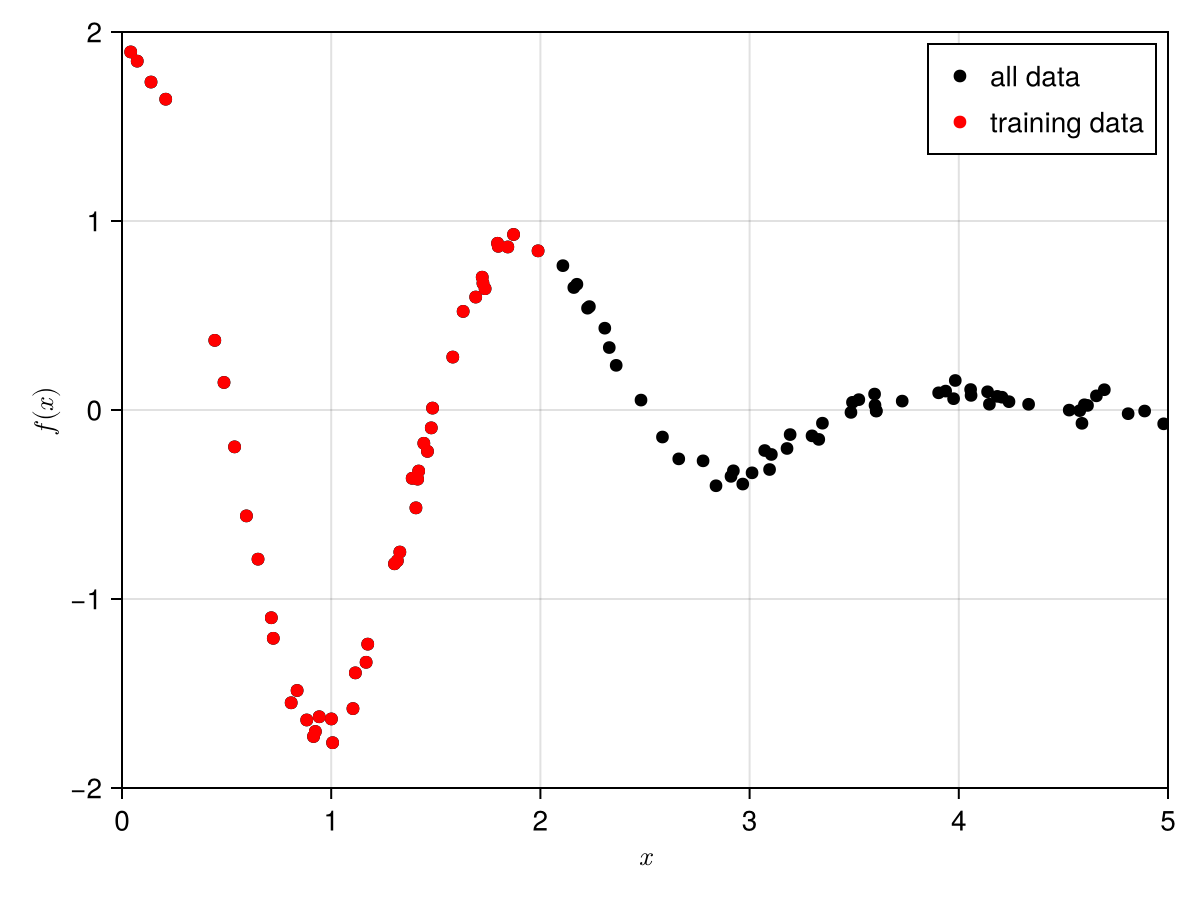

In [56]:
fig = Figure(backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor = :transparent,limits = (0,5, -2, 2))
scatter!(ax,xdata,ydata;color=:black,label="all data")
scatter!(ax,xtraining,ytraining;color=:red,label="training data")
axislegend(ax,location=:rt)
save("../figures/06p03NeuralNetworkWithJuliaPart202.png",fig)
fig

In [57]:
model_training = Chain(Dense(1 => 5,tanh),
Dense(5 => 5,tanh),
Dense(5=>1))

# Initialize the model weights and state
rng = Random.default_rng()
ps, ls = Lux.setup(rng, model_training)

((layer_1 = (weight = Float32[2.070374; 0.8509132; … ; 2.0901117; 1.6396333;;], bias = Float32[-0.40130138, -0.9151753, 0.53922653, 0.4958433, -0.48764384]), layer_2 = (weight = Float32[-0.8765004 -0.577796 … -0.53373903 -1.0062816; 1.1911608 -0.37699553 … -1.0417581 -0.7501479; … ; 0.47040224 -0.20209293 … 1.2774144 0.3785936; 1.271577 1.1008525 … -0.3085536 -0.16852304], bias = Float32[0.30622965, -0.4079655, 0.330182, -0.22390641, 0.09193247]), layer_3 = (weight = Float32[0.1711138 -0.5143709 … 0.24493201 -0.6530002], bias = Float32[-0.24454579])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

In [58]:
# The loss function
function loss_training(ps, ytraining)
    ypred,_=model_training(xtraining', ps, ls)
    loss = 0.5 * mean((ypred.-ytraining').^2)
    return loss
end

callback = function (p, l)
    if length(loss_history) % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction(loss_training, adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(ps),ytraining)

# Initialize a vector to store loss values
loss_history = Float64[]
neural_network = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.01); callback, maxiters = 10000)

ps=neural_network.u

Iteration: 1, Loss: 0.4686471614065544
Iteration: 101, Loss: 0.002950726356271961
Iteration: 201, Loss: 0.0021873024346733745
Iteration: 301, Loss: 0.0020889237483738957
Iteration: 401, Loss: 0.002041613366217326
Iteration: 501, Loss: 0.001971482870789316
Iteration: 601, Loss: 0.0017586463545223592
Iteration: 701, Loss: 0.001572416314150228
Iteration: 801, Loss: 0.001450814645188383
Iteration: 901, Loss: 0.001384659038662949
Iteration: 1001, Loss: 0.0013532741222446808
Iteration: 1101, Loss: 0.0013369435153659374
Iteration: 1201, Loss: 0.0013271221888486874
Iteration: 1301, Loss: 0.0013204042111605594
Iteration: 1401, Loss: 0.0013150131632756895
Iteration: 1501, Loss: 0.0013103122923409304
Iteration: 1601, Loss: 0.0013059792246536894
Iteration: 1701, Loss: 0.001302069750057689
Iteration: 1801, Loss: 0.0012980756919141535
Iteration: 1901, Loss: 0.0012951050901483384
Iteration: 2001, Loss: 0.0012910378347435131
Iteration: 2101, Loss: 0.001294725620131405
Iteration: 2201, Loss: 0.00128476

ComponentVector{Float32}(layer_1 = (weight = Float32[2.665926; 1.1251196; … ; 1.3253365; 1.8408302;;], bias = Float32[-0.95943457, -1.5681283, 1.1798577, 1.383915, -0.7259732]), layer_2 = (weight = Float32[-1.3812964 -1.375309 … 0.0053010136 -1.5502324; 1.6402862 -1.2077146 … -0.9779316 -0.4247312; … ; 1.1548569 -5.41425 … 2.4765456 0.98229724; 1.562189 0.8214901 … 0.10796843 0.11923442], bias = Float32[0.85215396, -0.4018001, 0.49734956, 0.85349375, 0.50053585]), layer_3 = (weight = Float32[0.7923084 -0.99921674 … 0.76581377 -0.8059152], bias = Float32[-0.062539026]))

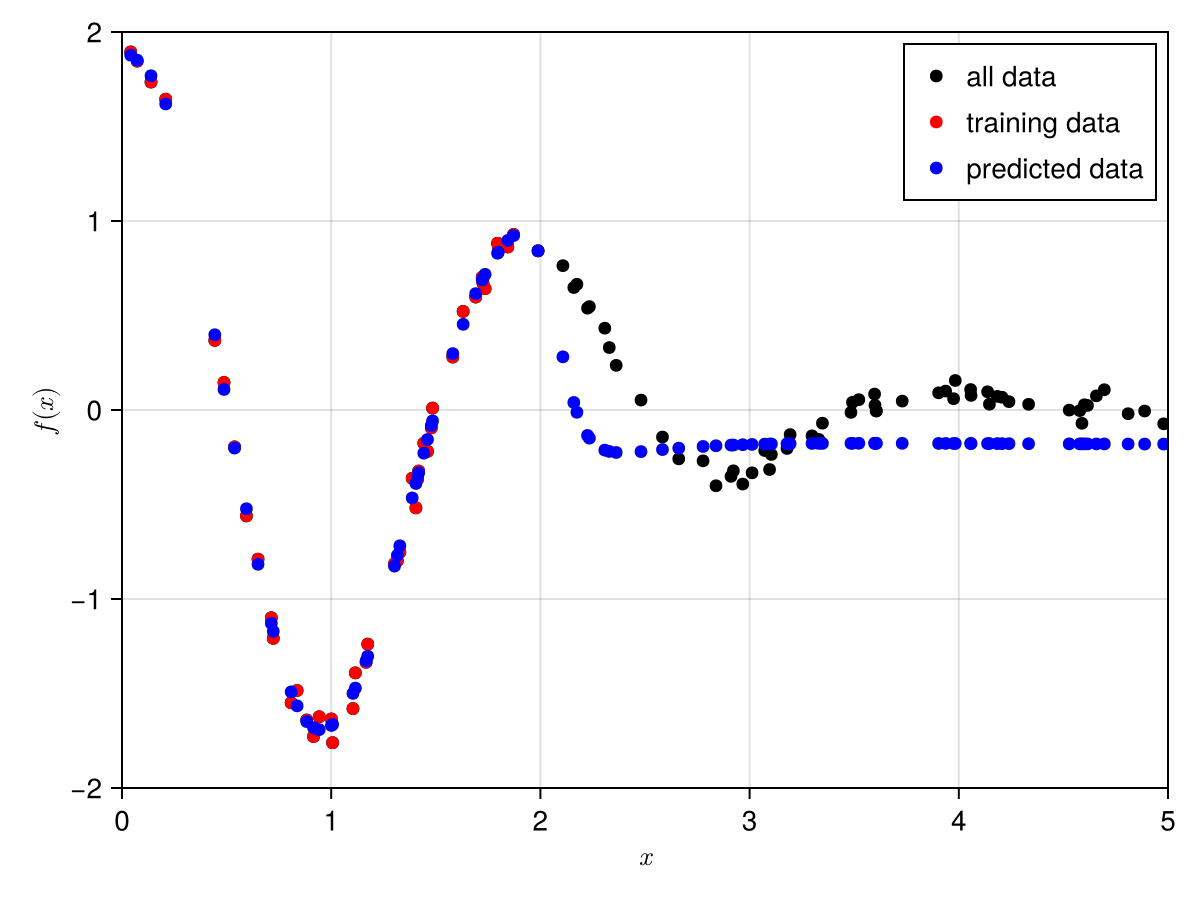

In [59]:
fig = Figure(backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor = :transparent,limits = (0,5, -2, 2))
scatter!(ax,xdata,ydata;color=:black,label="all data")
scatter!(ax,xtraining,ytraining;color=:red,label="training data")
scatter!(ax,xdata,model_training(xdata',ps,ls)[1][:];color=:blue,label="predicted data")
axislegend(ax,location=:rt)
#save("../figures/06p03NeuralNetworkWithJuliaPart202.png",fig)
fig

Finding the mean squared error between training and validation dataset.

In [60]:
validation_indices=setdiff(1:N_SAMPLES,training_indices)
ypred,_=model_training(xdata[validation_indices]', ps, ls)
mean((ypred.-ydata[validation_indices]').^2)

0.08594844837399783

---

**Class Demo 01:** Construct a  Neural Network using Lux in Julia to fit a limited section of the data in "Data06.csv".  Then try using this
Neural Network to predict the data beyond the training region

---